<h1 style="text-align: center; font-size: 40px; color: gray; font-weight: 700; margin-bottom: 5px;">
    DATA ANALYSIS PROJECT
</h1>
<h2 style="text-align: center; font-weight: 500; margin-top: 0;">
    Use Case : ASTRO
</h2>

# **Import Library**

In [169]:
# Basic libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as sc
import statsmodels as sm
pd.set_option('display.max_columns', None)

import warnings
warnings.filterwarnings('ignore')

# **Business Understanding**

## **1. Background**
Revolusi belanja kebutuhan sehari-hari (groceries) di Indonesia memasuki babak baru dengan hadirnya model Quick Commerce yang dipelopori oleh Astro. Menawarkan janji pengiriman ultra-cepat dalam waktu 15 menit, Astro mengubah total paradigma logistik ritel. Alih-alih menggunakan toko fisik yang bisa dikunjungi pelanggan atau mengambil barang dari supermarket mitra, Astro membangun jaringan Dark Stores (gudang tertutup atau hub) yang tersebar secara strategis di tengah pemukiman padat dan kawasan perkantoran.
Mengeksekusi janji 15 menit ini adalah sebuah keajaiban operasional yang membutuhkan presisi tingkat milidetik. Begitu pelanggan menekan tombol checkout di aplikasi, pesanan langsung masuk ke scanner para Picker (petugas gudang) yang harus berlari menyusuri lorong rak untuk mengumpulkan barang dalam waktu kurang dari 3 menit. Setelah itu, Packer mengemas pesanan, dan memberikannya ke Rider (kurir khusus Astro) yang sudah standby di luar untuk segera melesat ke rumah pelanggan.

Namun, mengoperasikan ratusan Dark Store dengan kecepatan tinggi ini mulai menimbulkan "kanker" operasional. Manajemen dibanjiri komplain pelanggan dan permintaan refund karena pesanan sering kali datang terlambat (SLA Miss), meleset jauh dari janji 15 menit, terutama saat peak hour (jam sibuk) atau hujan. Setelah ditelusuri, bottleneck (kemacetan) ternyata sering terjadi di dalam Dark Store itu sendiri. Banyak Picker yang kebingungan mencari barang karena layout rak yang tidak rapi, atau karena stok fisik barang ternyata sudah kosong padahal di sistem aplikasi masih tersedia (Phantom Inventory).

Masalah semakin runyam di sisi inventaris. Berbeda dengan logistik biasa, Astro banyak menjual produk segar (Fresh Produce) seperti sayur, daging, dan es krim yang sangat bergantung pada Cold Chain (rantai dingin). Tim Finance menemukan lonjakan kerugian akibat Shrinkage (penyusutan barang rusak). Banyak pesanan es krim yang sampai dalam keadaan mencair, atau buah yang sudah busuk, yang berujung pada kerugian ganda: perusahaan harus me-refund uang pelanggan dan membuang inventaris yang rusak. Di level data, log waktu picking dan delivery dari aplikasi internal sering kali kotor dan tidak logis, menutupi akar masalah yang sebenarnya.

Oleh karena itu, investigasi berbasis data terhadap kecepatan Picker, durasi delivery Rider, dan tingkat kerusakan produk segar ini mutlak harus dilakukan. Tanpa adanya pembersihan log waktu operasional dan identifikasi bottleneck di level Dark Store, Astro akan terus membakar uang investor untuk membayar kompensasi keterlambatan, membuang bahan makanan busuk, dan pada akhirnya gagal mempertahankan janji "15 Menit" yang menjadi satu-satunya nilai jual utama mereka.

## **2. Problem Statement**
**Masalah Utama**: Tingginya kerugian operasional akibat pelanggaran janji SLA 15-Menit (SLA Miss) serta kerugian inventaris dari kerusakan produk segar (Cold Chain Spoilage) di jaringan Dark Store.

**Masalah Turunan**:
* Dark Store mana yang memiliki rata-rata waktu Picking terburuk (lebih dari 3 menit) yang menjadi biang kerok keterlambatan pengiriman?
* Kategori produk segar apa (Fresh Produce / Ice Cream) yang paling sering dikomplain karena rusak/mencair saat diterima pelanggan?
* Seberapa besar lonjakan pelanggaran SLA 15-Menit yang terjadi secara spesifik saat kondisi cuaca memburuk (hujan/malam hari)?
* Berapa parah ketidakkonsistenan penulisan kategori produk yang di-input manual oleh admin Dark Store dari berbagai area?
* (Logical Error) Berapa banyak pesanan yang di sistem tercatat sudah 'Delivered' (Sampai ke Pelanggan), namun jam 'Picking Completed' (Selesai Dikemas) tercatat sesudah jam pengantaran tersebut?
* Berapa banyak Outliers ekstrem di mana durasi pengiriman (Delivery Duration) tercatat bernilai negatif atau memakan waktu ratusan ribu menit (bug sistem)?

## **3. Goals**
Goals bisnisnya adalah:
* **Dark Store Optimization**: Mengidentifikasi layout Dark Store yang bermasalah agar barang-barang Fast-Moving (paling sering dibeli) diletakkan di rak terdepan, memangkas waktu Picker hingga 40%.
* **SLA Enforcement**: Membangun dashboard peringatan dini jika Rider di suatu hub mulai kekurangan armada, sehingga aplikasi bisa mematikan janji 15 menit secara dinamis.
* **Waste Reduction**: Memperketat SOP Cold Chain untuk produk es krim dan daging segar guna menekan rasio refund akibat barang mencair/busuk.
* **Data Integrity**: Menutup celah bug di aplikasi internal agar Picker dan Rider tidak bisa memanipulasi tombol "Selesai" untuk mengelabui metrik KPI harian mereka.

# **Data**

## **Deskripsi Dataset**

### **Dataset 1 - Darkstores**

| Nama Kolom | Tipe Data | Deskripsi |
| :--- | :--- | :--- |
| **`store_id`** | Numerik | Kode unik Dark Store. |
| **`region`** | Kategorikal | Wilayah operasional (Jaksel, Jakpus, Tangsel, dll). |
| **`picker_headcount`** | Numerik | Jumlah Picker aktif di gudang tersebut (Jika jumlahnya kecil tapi ordernya banyak = bottleneck). |

### **Dataset 2 - Product**

| Nama Kolom | Tipe Data | Deskripsi |
| :--- | :--- | :--- |
| **`sku_id`** | Numerik | ID unik barang. |
| **`product_name`** | Kategorikal | Nama barang. |
| **`category`** | Kategorikal | Kategori produk. |
| **`is_perishable`** | Kategorikal | Apakah barang mudah rusak/busuk? (True/False). |

### **Dataset 3 - Orders**

| Nama Kolom | Tipe Data | Deskripsi |
| :--- | :--- | :--- |
| **`order_id`** | Numerik | ID unik pesanan. |
| **`store_id`** | Numerik | ID Dark Store yang memproses. |
| **`sku_id`** | Numerik | ID produk yang dibeli. |
| **`picker_id`** | Numerik | ID karyawan yang mengambil barang. |
| **`order_time`** | Numerik | Jam pelanggan klik Checkout. |
| **`picking_completed_time`** | Numerik | Jam Picker selesai memasukkan barang ke tas kurir. |
| **`delivered_time`** | Numerik | Jam Rider tiba di rumah pelanggan. |
| **`delivery_durations_mins`** | Numerik | Durasi total dari order sampai diantar dalam hitungan menit. |
| **`order_status`** | Kategorikal | Status pesanan (Completed, Refunded-Spoiled, Cancelled-Late). |

## **Dataset Preview**

### **Dataset 1 - Dark Stores**

In [170]:
# Load Dataset

darkstores_raw = pd.read_csv('astro_darkstores.csv')
darkstores = darkstores_raw.copy()

darkstores

,store_id,region,picker_headcount
0,AST-001,Jaksel,22
1,AST-002,Depok,23
2,AST-003,Depok,18
3,AST-004,Jaktim,11
4,AST-005,Jakut,16
...,...,...,...
145,AST-146,Jakpus,10
146,AST-147,Jaktim,18
147,AST-148,Jaktim,9
148,AST-149,Jakut,7


In [171]:
# Dataset General Information - Dark Stores

darkstores.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   store_id          150 non-null    str  
 1   region            150 non-null    str  
 2   picker_headcount  150 non-null    int64
dtypes: int64(1), str(2)
memory usage: 3.6 KB


In [172]:
# Statistical Summary

darkstores.describe()

,picker_headcount
count,150.000000
mean,14.413333
std,5.595044
min,5.000000
25%,10.000000
50%,15.000000
75%,19.000000
max,24.000000


**Catatan**
- Distribusi jumlah picker antar dark store menunjukkan variasi yang cukup besar.
- Rata-rata setiap dark store memiliki sekitar 14 picker, dengan rentang dari 5 hingga 24 picker.

In [173]:
# Cek Missing Value

darkstores.isna().sum()

store_id            0
region              0
picker_headcount    0
dtype: int64

**Catatan**
- Tidak ada entry yang missing.

In [174]:
# Cek Duplicated

darkstores.duplicated().sum()

np.int64(0)

**Catatan**
- Tidak ada entry yang duplikat.

In [175]:
# Cek Picker Head Count Negatif

darkstores[darkstores['picker_headcount'] <= 0]

,store_id,region,picker_headcount


**Catatan**
- Tidak ada Dark Stores dengan jumlah picker di bawah 0.

In [176]:
# Store per Region

darkstores['region'].value_counts()

region
Jaktim     30
Tangsel    29
Jakut      26
Jaksel     19
Jakbar     17
Depok      15
Jakpus     14
Name: count, dtype: int64

**Catatan**
- Jaktim menjadi region dengan store terbanyak, yakni 30 store.

### **Dataset 2 - Product**

In [177]:
# Load Dataset

prod_raw = pd.read_csv('astro_products.csv')
prod = prod_raw.copy()

prod

,sku_id,product_name,category,is_perishable
0,SKU-AST0001,Produk FMCG Kering 0,Snacks,False
1,SKU-AST0002,Produk FMCG Kering 1,Snacks,False
2,SKU-AST0003,Produk FMCG Kering 2,minuman,False
3,SKU-AST0004,Sayur/Daging Segar 3,syr,True
4,SKU-AST0005,Produk FMCG Kering 4,snack,False
...,...,...,...,...
395,SKU-AST0396,Produk FMCG Kering 395,snack,False
396,SKU-AST0397,Sayur/Daging Segar 396,syr,True
397,SKU-AST0398,Produk FMCG Kering 397,Beverages,False
398,SKU-AST0399,Produk FMCG Kering 398,Beverages,False


In [178]:
# General Information

prod.info()

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   sku_id         400 non-null    str  
 1   product_name   400 non-null    str  
 2   category       400 non-null    str  
 3   is_perishable  400 non-null    bool 
dtypes: bool(1), str(3)
memory usage: 9.9 KB


In [179]:
# Statistical Summary

prod.describe()

,sku_id,product_name,category,is_perishable
count,400,400,400,400
unique,400,400,9,2
top,SKU-AST0001,Produk FMCG Kering 0,Snacks,False
freq,1,1,77,250


In [180]:
# Cek Missing Value

prod.isna().sum()

sku_id           0
product_name     0
category         0
is_perishable    0
dtype: int64

In [181]:
# Cek Duplicated

prod.duplicated().sum()

np.int64(0)

In [182]:
# Cek Duplicated SKU

prod.duplicated(subset='sku_id').sum()

np.int64(0)

In [183]:
# Cek Kategori Produk

prod['category'].value_counts()

category
Snacks           77
Beverages        71
snack            57
Fresh Produce    53
minuman          45
Ice Cream        36
eskrim           23
syr              22
sayur            16
Name: count, dtype: int64

**Catatan**
Ditemukan penulisan kategori yang tidak konsisten
- Snacks dan snack
- Beverages dan minuman
- Ice Cream dan eskrim
- sayur dan syr

**Data tidak langsung di-cleaning untuk analisis, dan akan di-cleaning kemudian untuk analisis lebih lanjut.**

In [184]:
# Normalisasi penulisan kategori

prod['category'] = prod['category'].str.lower().str.strip()

In [185]:
# Mapping Inkonsistensi Penulisan Kategori

prod_cat = {
    'snack': 'snacks',
    'snacks': 'snacks',

    'minuman': 'beverages',
    'beverages': 'beverages',

    'eskrim': 'ice_cream',
    'ice cream': 'ice_cream',

    'sayur': 'sayur',
    'syr': 'sayur',

    'fresh produce': 'fresh_produce'
}

prod['category'] = prod['category'].replace(prod_cat)

In [186]:
# Check Replace Inkonsistensi Penulisan Kategori

prod['category'].unique()

<StringArray>
['snacks', 'beverages', 'sayur', 'fresh_produce', 'ice_cream']
Length: 5, dtype: str

**Catatan**
Setelah dilakukan cleaning untuk category, kini hanya ada lima kategori di dalam table, yakni:
- Snacks
- Beverages
- Sayur
- Fresh Produce
- Ice Cream

In [187]:
# Create Kolom Baru untuk Kategori Fresh Produce

prod['category_group'] = 'non_fresh'

prod.loc[
    prod['category'].isin(['sayur', 'fresh_produce', 'ice_cream']),
    'category_group'
] = 'fresh_produce'

In [188]:
prod[['category', 'category_group']].drop_duplicates()

,category,category_group
0,snacks,non_fresh
2,beverages,non_fresh
3,sayur,fresh_produce
5,fresh_produce,fresh_produce
7,ice_cream,fresh_produce


**Catatan**
- Meskipun kategori produk awal menunjukkan pemisahan antara "sayur", "fresh produce", dan "ice cream", ketiga kategori tersebut sebenarnya termasuk dalam kelompok produk mudah rusak (perishable).
- Oleh karena itu, dilakukan pengelompokan ulang ke dalam kategori yang lebih tinggi ("fresh_produce") untuk analisis spoilage, sambil tetap mempertahankan kategori asli untuk analisis yang lebih granular.

In [189]:
# Cek is_perishable

prod['is_perishable'].value_counts()

is_perishable
False    250
True     150
Name: count, dtype: int64

In [190]:
# Cross-check category - is_perishable

prod.groupby('category')['is_perishable'].value_counts()

category       is_perishable
beverages      False            116
fresh_produce  True              53
ice_cream      True              59
sayur          True              38
snacks         False            134
Name: count, dtype: int64

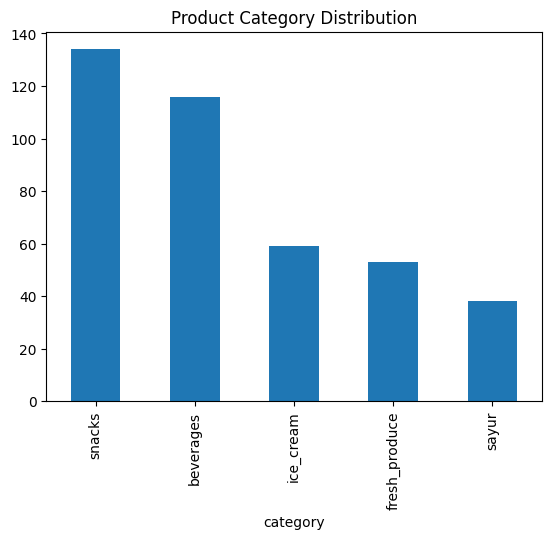

In [191]:
# Distribusi Kategori

prod['category'].value_counts().plot(kind='bar')
plt.title("Product Category Distribution")
plt.show()

**Catatan**
- Distribusi kategori paling banyak ada di Snacks dengan jumlah 134, diikuti Beverages
- Dua kategori teratas (paling banyak) merupakan produk yang tidak mudah rusak

### **Dataset 3 - Orders**

In [192]:
# Load Dataset

orders_raw = pd.read_csv('astro_orders.csv')
orders = orders_raw.copy()

orders

,order_id,store_id,sku_id,picker_id,order_time,picking_completed_time,delivered_time,delivery_duration_mins,order_status
0,ORD-AST00000001,AST-101,SKU-AST0304,NaN,2023-12-31 18:19:13,2023-12-31 18:24:07,2023-12-31 18:31:37,12.0,Completed
1,ORD-AST00000002,AST-016,SKU-AST0021,PCK-854,2023-12-24 20:43:04,2023-12-24 20:48:10,2023-12-24 20:55:12,12.0,Completed
2,ORD-AST00000003,AST-072,SKU-AST0307,NaN,2023-12-16 22:34:38,2023-12-16 22:36:48,2023-12-16 22:42:54,8.0,Completed
3,ORD-AST00000004,AST-007,SKU-AST0065,PCK-785,2023-12-20 20:09:11,2023-12-20 20:11:23,2023-12-20 20:17:45,8.0,Completed
4,ORD-AST00000005,AST-046,SKU-AST0174,PCK-567,2024-01-02 06:32:18,2024-01-02 06:35:19,2024-01-02 06:45:48,13.0,Completed
...,...,...,...,...,...,...,...,...,...
299995,ORD-AST00299996,AST-052,SKU-AST0103,PCK-501,2024-02-26 08:03:56,2024-02-26 08:09:14,2024-02-26 08:21:35,17.0,Completed
299996,ORD-AST00299997,AST-081,SKU-AST0051,PCK-972,2024-01-29 17:05:25,2024-01-29 17:09:55,2024-01-29 17:20:31,15.0,Completed
299997,ORD-AST00299998,AST-013,SKU-AST0074,PCK-906,2024-01-17 18:18:50,2024-01-17 18:29:59,2024-01-17 18:26:59,8.0,Completed
299998,ORD-AST00299999,AST-056,SKU-AST0035,PCK-453,2023-12-26 14:26:03,2023-12-26 14:31:54,2023-12-26 14:38:08,12.0,Completed


In [193]:
# General Information

orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 9 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_id                300000 non-null  str    
 1   store_id                300000 non-null  str    
 2   sku_id                  300000 non-null  str    
 3   picker_id               264000 non-null  str    
 4   order_time              300000 non-null  str    
 5   picking_completed_time  300000 non-null  str    
 6   delivered_time          278765 non-null  str    
 7   delivery_duration_mins  300000 non-null  float64
 8   order_status            300000 non-null  str    
dtypes: float64(1), str(8)
memory usage: 20.6 MB


**Catatan**
- Tipe Data `order_time`, `picking_completed_time`, dan `delivered_time` masih string, seharusnya date-time
- Akan dilakukan cleaning kemudian untuk analisis lebih lanjut.

In [194]:
# Konversi Tipe Data yang Masih Salah

orders['order_time'] = pd.to_datetime(orders['order_time'])
orders['picking_completed_time'] = pd.to_datetime(orders['picking_completed_time'])
orders['delivered_time'] = pd.to_datetime(orders['delivered_time'])

In [195]:
# Cek Kembali Tipe Data

orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 9 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   order_id                300000 non-null  str           
 1   store_id                300000 non-null  str           
 2   sku_id                  300000 non-null  str           
 3   picker_id               264000 non-null  str           
 4   order_time              300000 non-null  datetime64[us]
 5   picking_completed_time  300000 non-null  datetime64[us]
 6   delivered_time          278765 non-null  datetime64[us]
 7   delivery_duration_mins  300000 non-null  float64       
 8   order_status            300000 non-null  str           
dtypes: datetime64[us](3), float64(1), str(5)
memory usage: 20.6 MB


In [196]:
# Cek Missing Value

(orders.isna().sum()/len(orders)*100).sort_values(ascending=False)

picker_id                 12.000000
delivered_time             7.078333
order_id                   0.000000
store_id                   0.000000
sku_id                     0.000000
order_time                 0.000000
picking_completed_time     0.000000
delivery_duration_mins     0.000000
order_status               0.000000
dtype: float64

**Catatan**
- Terdapat Missing Value cukup besar di kolom picker_id (12%) dan delivered_time (7%)

In [197]:
# Investigasi Missing delivered_time

orders[orders['delivered_time'].isna()]['order_status'].value_counts()

order_status
Cancelled-Late    21235
Name: count, dtype: int64

**Catatan**
- 21.235 jumlah order dibatalkan sebelum sampai ke customer.

In [198]:
# Investigasi Missing picker_id

orders[orders['picker_id'].isna()]['order_status'].value_counts()

order_status
Completed           30530
Refunded-Spoiled     2882
Cancelled-Late       2588
Name: count, dtype: int64

**Catatan**
- Sekitar 12% pesanan tidak memiliki informasi picker_id, termasuk lebih dari 30 ribu pesanan yang berstatus Completed.
- Hal ini mengindikasikan adanya masalah dalam sistem pencatatan operasional, di mana aktivitas picking tidak selalu tercatat dengan benar.
- Data ini tidak langsung dibersihkan dan akan dianalisis lebih lanjut.

In [199]:
# Cek Duplicated

orders.duplicated().sum()

np.int64(0)

In [200]:
# Cek Duplicated Order ID

orders.duplicated(subset='order_id').sum()

np.int64(0)

In [201]:
# Cek Order Status Distribution

orders['order_status'].value_counts()

order_status
Completed           254584
Refunded-Spoiled     24181
Cancelled-Late       21235
Name: count, dtype: int64

In [ ]:
# Cek Outlier Delivery Duration

orders['delivery_duration_mins'].describe()

count    300000.000000
mean         48.315547
std         570.397076
min         -15.000000
25%          11.000000
50%          13.000000
75%          15.000000
max        9999.000000
Name: delivery_duration_mins, dtype: float64

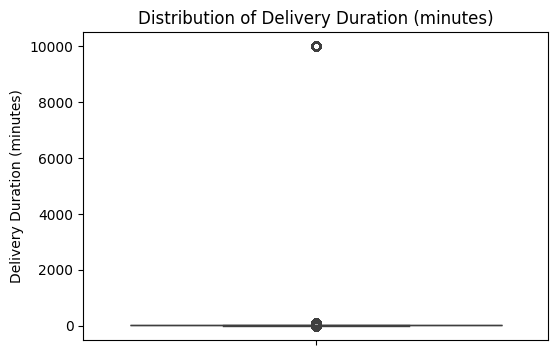

In [255]:
# Boxplot delivery_duration_mins

plt.figure(figsize=(6, 4))
sns.boxplot(y=orders_raw['delivery_duration_mins'])
plt.title('Distribution of Delivery Duration (minutes)')
plt.ylabel('Delivery Duration (minutes)')
plt.show()

**Catatan**
- Didapatkan ada angka yang tidak masuk akal di kolom Delivery Duration.
- Paling kecil ada di angka -15 menit.
- Paling besar ada di angka 9999 menit (sekitar 7 hari).
- Menyebabkan rata-rata (mean) pengiriman di 48 menit tidak valid.

In [203]:
# Cek Nilai Aneh di Delivery Duration

orders[orders['delivery_duration_mins'] < 0]

,order_id,store_id,sku_id,picker_id,order_time,picking_completed_time,delivered_time,delivery_duration_mins,order_status
494,ORD-AST00000495,AST-047,SKU-AST0237,PCK-730,2023-12-04 07:20:27,2023-12-04 07:24:49,2023-12-04 07:30:13,-15.0,Completed
590,ORD-AST00000591,AST-077,SKU-AST0161,PCK-183,2024-02-19 12:00:13,2024-02-19 12:03:13,2024-02-19 12:12:29,-15.0,Completed
754,ORD-AST00000755,AST-129,SKU-AST0390,PCK-390,2023-12-22 11:50:25,2023-12-22 11:52:48,2023-12-22 12:03:19,-15.0,Completed
968,ORD-AST00000969,AST-017,SKU-AST0212,PCK-739,2024-02-13 11:05:47,2024-02-13 11:08:04,2024-02-13 11:15:13,-15.0,Completed
1402,ORD-AST00001403,AST-132,SKU-AST0250,PCK-865,2024-01-09 17:43:32,2024-01-09 17:47:18,2024-01-09 17:57:22,-15.0,Completed
...,...,...,...,...,...,...,...,...,...
298129,ORD-AST00298130,AST-074,SKU-AST0040,PCK-935,2023-12-10 06:04:22,2023-12-10 06:07:14,2023-12-10 06:12:56,-15.0,Completed
298197,ORD-AST00298198,AST-087,SKU-AST0348,PCK-849,2024-01-14 16:19:29,2024-01-14 16:25:01,2024-01-14 16:36:15,-15.0,Completed
298714,ORD-AST00298715,AST-069,SKU-AST0030,PCK-620,2024-02-04 16:12:48,2024-02-04 16:14:48,NaT,-15.0,Cancelled-Late
298907,ORD-AST00298908,AST-055,SKU-AST0019,PCK-726,2024-01-01 19:02:52,2024-01-01 19:05:12,2024-01-01 19:11:46,-15.0,Completed


**Catatan**
- Terdapat 1032 entry dengan Delivery Duration di bawah 0 menit

In [204]:
# Cek Nilai Aneh di Delivery Duration

orders[orders['delivery_duration_mins'] > 1000]

,order_id,store_id,sku_id,picker_id,order_time,picking_completed_time,delivered_time,delivery_duration_mins,order_status
582,ORD-AST00000583,AST-150,SKU-AST0119,PCK-818,2024-02-24 19:20:01,2024-02-24 19:24:58,2024-02-24 19:34:23,9999.0,Completed
811,ORD-AST00000812,AST-078,SKU-AST0389,PCK-171,2023-12-31 08:07:48,2023-12-31 08:10:16,2023-12-31 08:19:42,9999.0,Completed
978,ORD-AST00000979,AST-068,SKU-AST0108,PCK-521,2024-02-07 13:45:41,2024-02-07 13:47:59,2024-02-07 13:59:51,9999.0,Completed
1378,ORD-AST00001379,AST-060,SKU-AST0256,PCK-879,2024-01-27 08:20:26,2024-01-27 08:25:08,2024-01-27 08:33:46,9999.0,Completed
1399,ORD-AST00001400,AST-139,SKU-AST0296,PCK-736,2023-12-18 19:58:58,2023-12-18 20:02:48,2023-12-18 20:09:11,9999.0,Completed
...,...,...,...,...,...,...,...,...,...
298064,ORD-AST00298065,AST-104,SKU-AST0186,PCK-533,2024-02-02 19:53:50,2024-02-02 19:55:58,2024-02-02 20:05:58,9999.0,Completed
299500,ORD-AST00299501,AST-150,SKU-AST0135,PCK-625,2024-02-21 12:40:38,2024-02-21 12:44:30,2024-02-21 12:53:47,9999.0,Completed
299584,ORD-AST00299585,AST-135,SKU-AST0254,PCK-359,2024-01-29 18:47:20,2024-01-29 18:52:54,2024-01-29 19:03:04,9999.0,Completed
299729,ORD-AST00299730,AST-032,SKU-AST0154,NaN,2024-01-03 22:02:33,2024-01-03 22:08:21,2024-01-03 22:18:38,9999.0,Completed


**Catatan**
- Terdapat 982 entry dengan durasi pengiriman di 9999 menit

In [254]:
# Flag Delivery Duration

orders['duration_error_flag'] = (
    (orders['delivery_duration_mins'] < 0) |
    (orders['delivery_duration_mins'] > 120)
)

orders['duration_error_flag'].mean()

np.float64(0.006713333333333333)

**Catatan**
- 0,67 persen data yang error di kolom Delivery Duration

In [206]:
# Filter data yang valid

orders_clean = orders[
    (orders['delivery_duration_mins'] >= 0) &
    (orders['delivery_duration_mins'] <= 120)
]

In [207]:
# Perbandingan data sebelum dan setelah di-cleaning
orders['delivery_duration_mins'].describe()
orders_clean['delivery_duration_mins'].describe()

count    297986.000000
mean         15.742773
std          13.132968
min           0.000000
25%          11.000000
50%          13.000000
75%          15.000000
max          89.000000
Name: delivery_duration_mins, dtype: float64

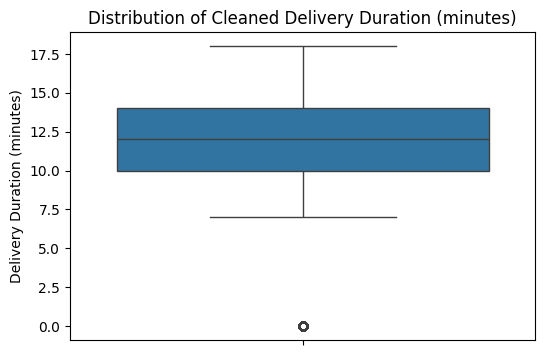

In [256]:
# Boxplot delivery_duration_mins setelah di-cleaning

plt.figure(figsize=(6, 4))
sns.boxplot(y=orders_clean['delivery_duration_mins'])
plt.title('Distribution of Cleaned Delivery Duration (minutes)')
plt.ylabel('Delivery Duration (minutes)')
plt.show()

**Catatan**
- Terlihat perubahan drastis etelah dilakukan cleaning data di kolom Delivery Duration
- Rata-rata pengiriman menjadi 15,7 menit
- Pengiriman terlama berada di angka 89 menit

In [208]:
# Cek lanjutan Duration Error - Order Status

orders[orders['duration_error_flag']]['order_status'].value_counts()

order_status
Completed           1737
Refunded-Spoiled     156
Cancelled-Late       121
Name: count, dtype: int64

**Catatan**
- Dari data yang error banyak yang dinyatakan tetap completed.

In [209]:
# Cek Logical Error delivered_time < picking_completed_time

logical_error = orders[
    orders['delivered_time'] < orders['picking_completed_time']
]

len(logical_error)

8910

**Catatan**
- 8910 (sekitar 3 persen) pesanan memiliki urutan waktu yang tidak logis, di mana pesanan tercatat telah dikirim sebelum proses picking selesai.

In [210]:
# Cleaning error delivered_time < picking_completed_time

orders_clean = orders[
    (orders['delivery_duration_mins'] >= 0) &
    (orders['delivery_duration_mins'] <= 120) &
    (orders['delivered_time'] >= orders['picking_completed_time'])
]

In [211]:
# Simpan error delivered_time < picking_completed_time

orders['logical_error_flag'] = (
    orders['delivered_time'] < orders['picking_completed_time']
)

In [212]:
# Cek lanjutan

orders[orders['logical_error_flag']]['order_status'].value_counts()

order_status
Completed    8910
Name: count, dtype: int64

**Catatan**
- Semua order dengan data yang tidak logis dinyatakan completed

In [213]:
# Copy dataframe orders

orders_clean = orders[
    (orders['delivery_duration_mins'] >= 0) &
    (orders['delivery_duration_mins'] <= 120) &
    (orders['delivered_time'] >= orders['picking_completed_time'])
].copy()

In [214]:
# Cek Picking Duration

orders_clean['picking_duration_mins'] = (
    orders_clean['picking_completed_time'] - orders_clean['order_time']
).dt.total_seconds() / 60

orders_clean['picking_duration_mins'].describe()

count    268027.000000
mean          3.981534
std           1.153290
min           2.000000
25%           2.966667
50%           3.966667
75%           4.966667
max           5.966667
Name: picking_duration_mins, dtype: float64

**Catatan**
- Setelah menghilangkan anomali data, rata-rata waktu picking tercatat sebesar 3.98 menit
- Masih berada di atas target operasional 3 menit

In [215]:
# Cek KPI

orders_clean['picking_sla_miss'] = orders_clean['picking_duration_mins'] > 3
orders_clean['picking_sla_miss'].mean()

np.float64(0.7452271599503035)

**Catatan**
- Sebanyak 74.5% pesanan membutuhkan waktu picking lebih dari 3 menit, menunjukkan bahwa mayoritas dark store gagal memenuhi target operasional internal
- Indikasi bottleneck utama dalam pemenuhan janji SLA 15 menit bukan terletak pada proses pengiriman, melainkan pada tahap picking di dalam gudang

# **Data Analysis**

## **1. Dark Store mana yang memiliki rata-rata waktu Picking terburuk (lebih dari 3 menit) yang menjadi biang kerok keterlambatan pengiriman?**

In [216]:
# Join Dataframe Orders & Darkstores

df = orders_clean.merge(darkstores, on='store_id', how='left')

In [217]:
# Hitung Performa per Store

store_picking = df.groupby('store_id').agg(
    avg_picking=('picking_duration_mins', 'mean'),
    total_orders=('order_id', 'count'),
    picker_headcount=('picker_headcount', 'mean')
).reset_index()

store_picking

,store_id,avg_picking,total_orders,picker_headcount
0,AST-001,3.996607,1778,22.0
1,AST-002,3.994739,1847,23.0
2,AST-003,3.975706,1794,18.0
3,AST-004,3.916936,1856,11.0
4,AST-005,3.962679,1789,16.0
...,...,...,...,...
145,AST-146,3.976258,1729,10.0
146,AST-147,3.964815,1809,18.0
147,AST-148,4.004686,1782,9.0
148,AST-149,3.989424,1754,7.0


In [218]:
# Filter Store Bermasalah > 3 Menit

problem_store = store_picking[
    store_picking['avg_picking'] > 3
].sort_values('avg_picking', ascending=False)

problem_store

,store_id,avg_picking,total_orders,picker_headcount
24,AST-025,4.064909,1707,5.0
91,AST-092,4.038364,1799,19.0
75,AST-076,4.035435,1737,5.0
25,AST-026,4.032136,1726,12.0
101,AST-102,4.031714,1832,15.0
...,...,...,...,...
97,AST-098,3.928143,1718,19.0
72,AST-073,3.922711,1806,5.0
3,AST-004,3.916936,1856,11.0
105,AST-106,3.916023,1788,19.0


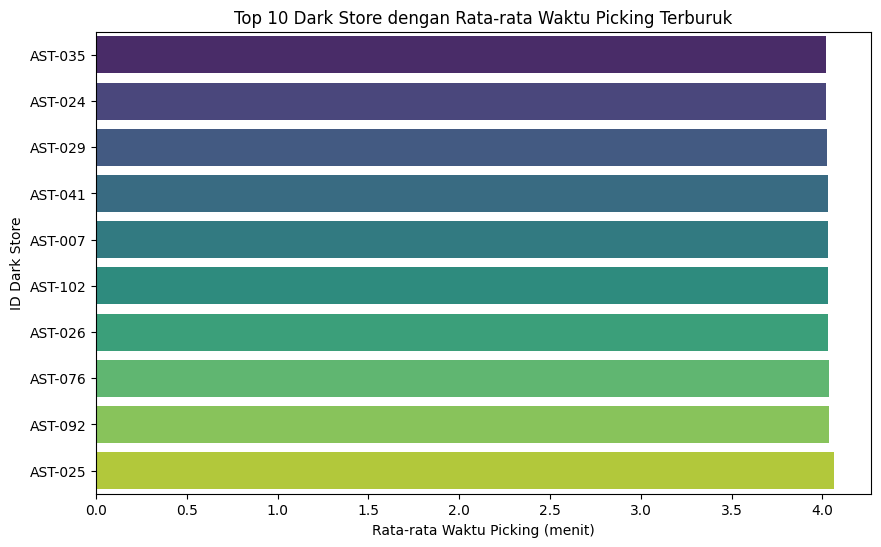

In [257]:
# 10 Teratas Dark Store dengan Performa buruk
top10 = problem_store.head(10)

plt.figure(figsize=(10, 6)) # Adjusted figure size for better readability
sns.barplot(x='avg_picking', y='store_id', data=top10.sort_values(by='avg_picking', ascending=True), palette='viridis')
plt.xlabel('Rata-rata Waktu Picking (menit)')
plt.ylabel('ID Dark Store')
plt.title('Top 10 Dark Store dengan Rata-rata Waktu Picking Terburuk')
plt.show()

**Catatan**
- Top 10 dark store dengan performa picking terburuk menunjukkan rata-rata waktu picking yang relatif seragam, berkisar di sekitar 4 menit.
- Hampir seluruh store memiliki performa picking yang buruk atau di atas 3 menit.
- Hal ini mengindikasikan bahwa keterlambatan bukan disebabkan oleh beberapa store ekstrem, melainkan merupakan masalah operasional yang terjadi secara konsisten di berbagai lokasi.

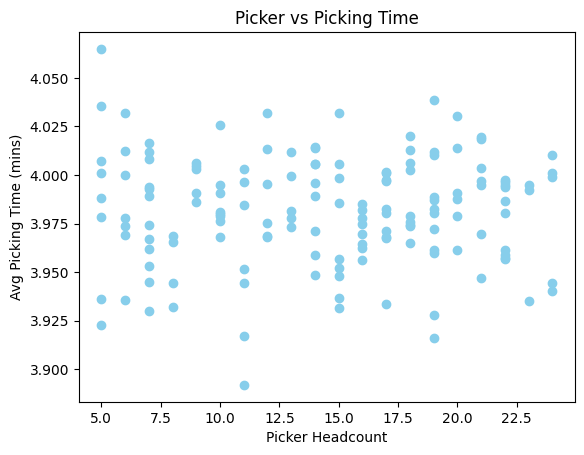

In [259]:
# Visualisasi Scatter Plot Perbandingan Jumlah Picker dan Avg Picking Time

plt.figure()
plt.scatter(store_picking['picker_headcount'], store_picking['avg_picking'], c='skyblue')
plt.xlabel('Picker Headcount')
plt.ylabel('Avg Picking Time (mins)')
plt.title('Picker vs Picking Time')
plt.show()

**Catatan**
- Meskipun terdapat variasi jumlah picker antar dark store, tidak ditemukan hubungan yang signifikan antara jumlah picker dengan durasi picking.
- Bahkan store dengan jumlah picker yang lebih besar tetap menunjukkan waktu picking yang tinggi.
- Hal ini mengindikasikan bahwa bottleneck utama bukan disebabkan oleh kekurangan tenaga kerja, melainkan oleh inefisiensi sistem operasional di dalam gudang, seperti layout rak yang tidak optimal atau proses pencarian barang yang tidak efisien.

## **2. Kategori produk segar apa (Fresh Produce / Ice Cream) yang paling sering dikomplain karena rusak/mencair saat diterima pelanggan?**

In [221]:
# Merge Dataframe prod ke df

df = df.merge(prod, on='sku_id', how='left')
df

,order_id,store_id,sku_id,picker_id,order_time,picking_completed_time,delivered_time,delivery_duration_mins,order_status,duration_error_flag,logical_error_flag,picking_duration_mins,picking_sla_miss,region,picker_headcount,product_name,category,is_perishable,category_group
0,ORD-AST00000001,AST-101,SKU-AST0304,NaN,2023-12-31 18:19:13,2023-12-31 18:24:07,2023-12-31 18:31:37,12.0,Completed,False,False,4.900000,True,Depok,22,Produk FMCG Kering 303,snacks,False,non_fresh
1,ORD-AST00000002,AST-016,SKU-AST0021,PCK-854,2023-12-24 20:43:04,2023-12-24 20:48:10,2023-12-24 20:55:12,12.0,Completed,False,False,5.100000,True,Jaktim,11,Produk FMCG Kering 20,snacks,False,non_fresh
2,ORD-AST00000003,AST-072,SKU-AST0307,NaN,2023-12-16 22:34:38,2023-12-16 22:36:48,2023-12-16 22:42:54,8.0,Completed,False,False,2.166667,False,Tangsel,17,Sayur/Daging Segar 306,sayur,True,fresh_produce
3,ORD-AST00000004,AST-007,SKU-AST0065,PCK-785,2023-12-20 20:09:11,2023-12-20 20:11:23,2023-12-20 20:17:45,8.0,Completed,False,False,2.200000,False,Tangsel,6,Produk FMCG Kering 64,snacks,False,non_fresh
4,ORD-AST00000005,AST-046,SKU-AST0174,PCK-567,2024-01-02 06:32:18,2024-01-02 06:35:19,2024-01-02 06:45:48,13.0,Completed,False,False,3.016667,True,Jakbar,15,Es Krim Rasa Vanilla 173,fresh_produce,True,fresh_produce
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
268022,ORD-AST00299995,AST-117,SKU-AST0070,PCK-709,2024-01-27 12:57:53,2024-01-27 13:02:18,2024-01-27 13:07:30,9.0,Completed,False,False,4.416667,True,Jaktim,21,Produk FMCG Kering 69,snacks,False,non_fresh
268023,ORD-AST00299996,AST-052,SKU-AST0103,PCK-501,2024-02-26 08:03:56,2024-02-26 08:09:14,2024-02-26 08:21:35,17.0,Completed,False,False,5.300000,True,Jakut,19,Produk FMCG Kering 102,beverages,False,non_fresh
268024,ORD-AST00299997,AST-081,SKU-AST0051,PCK-972,2024-01-29 17:05:25,2024-01-29 17:09:55,2024-01-29 17:20:31,15.0,Completed,False,False,4.500000,True,Tangsel,10,Sayur/Daging Segar 50,sayur,True,fresh_produce
268025,ORD-AST00299999,AST-056,SKU-AST0035,PCK-453,2023-12-26 14:26:03,2023-12-26 14:31:54,2023-12-26 14:38:08,12.0,Completed,False,False,5.850000,True,Tangsel,14,Es Krim Rasa Vanilla 34,ice_cream,True,fresh_produce


In [222]:
# Filter Produk yang Spoil

spoil = df[df['order_status'] == 'Refunded-Spoiled']

In [223]:
# Kategori yang Paling Banyak Kasus

spoil.groupby('category').size().sort_values(ascending=False)

category
snacks           8025
beverages        6930
ice_cream        3584
fresh_produce    3153
sayur            2333
dtype: int64

**Catatan**
- Snacks dan Beverages paling banyak rusak, kemungkinan besar karena jumlah order yang banyak

In [224]:
# Kategori yang Paling Berisiko Rusak

spoil_rate = df.groupby('category')['order_status'].value_counts(normalize=True).unstack()
spoil_rate['Refunded-Spoiled'].sort_values(ascending=False)

category
sayur            0.091887
ice_cream        0.090725
snacks           0.089520
beverages        0.089046
fresh_produce    0.088411
Name: Refunded-Spoiled, dtype: float64

**Catatan**
| category      | spoil rate |
| ------------- | ---------- |
| sayur         | **9.19%**  |
| ice_cream     | 9.07%      |
| snacks        | 8.95%      |
| beverages     | 8.90%      |
| fresh_produce | 8.84%      |

- Sementara dilihat dari spoil rate, sayur dan ice cream tertinggi.
- Akan tetapi, gap dengan produk non fresh produce kecil.
- Artinya, semua kategori punya spoilage rate yang tinggi.

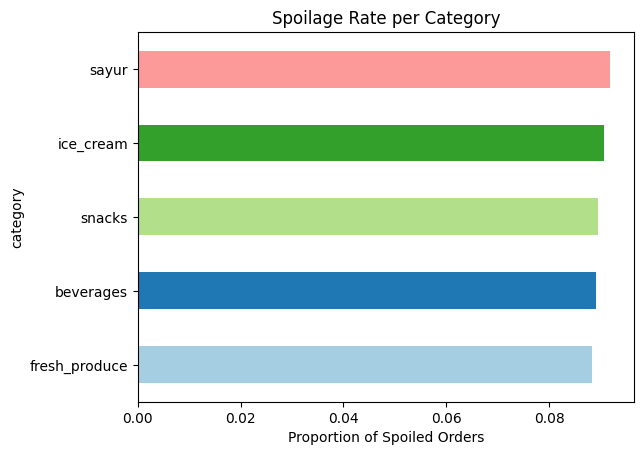

In [261]:
# Chart Spoilage Rate

spoil_rate['Refunded-Spoiled'].sort_values().plot(kind='barh', color=plt.cm.Paired.colors)
plt.title('Spoilage Rate per Category')
plt.xlabel('Proportion of Spoiled Orders')
plt.show()

**Catatan**
- Meskipun kategori fresh produce seperti sayur dan ice cream menunjukkan tingkat spoilage tertinggi, perbedaannya relatif kecil dibandingkan kategori non-fresh.
- Hal ini mengindikasikan bahwa kerusakan produk tidak hanya disebabkan oleh karakteristik produk, tetapi juga oleh keterlambatan dalam proses operasional.
- Dengan kata lain, masalah utama bukan hanya pada cold chain, melainkan pada inefisiensi proses picking dan delivery yang berdampak pada seluruh kategori produk.

## **3. Seberapa besar lonjakan pelanggaran SLA 15-Menit yang terjadi secara spesifik saat kondisi cuaca memburuk (hujan/malam hari)?**

In [226]:
# Create Kolom Waktu

df['hour'] = df['order_time'].dt.hour

In [227]:
# Klasifikasi Waktu Malam
# 19.00 - 05.59

df['is_night'] = (
    (df['hour'] >= 19) | (df['hour'] <= 5)
)

In [228]:
# SLA Flag

df['delivery_sla_miss'] = df['delivery_duration_mins'] > 15

In [229]:
# Perbandingan SLA Miss

df.groupby('is_night')['delivery_sla_miss'].mean()

is_night
False    0.137481
True     0.136270
Name: delivery_sla_miss, dtype: float64

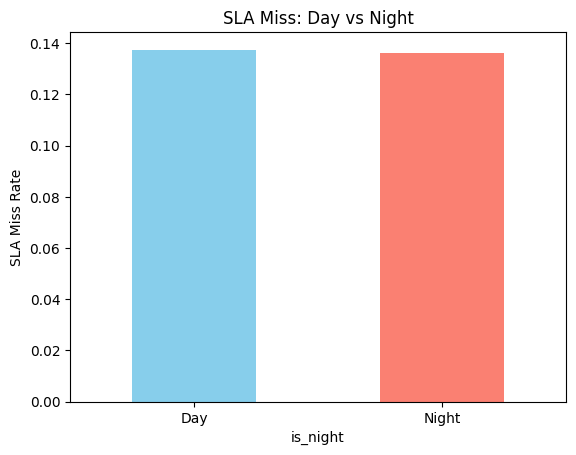

In [263]:
# Bar Chart Perbandingan SLA Miss Day vs Night

df.groupby('is_night')['delivery_sla_miss'].mean().plot(kind='bar', color=['skyblue', 'salmon'])
plt.xticks([0,1], ['Day', 'Night'], rotation=0)
plt.ylabel('SLA Miss Rate')
plt.title('SLA Miss: Day vs Night')
plt.show()

**Catatan**
- Dataset tidak menyediakan informasi kondisi cuaca, sehingga analisis dampak hujan tidak dapat dilakukan secara langsung.
- Perbandingan dilakukan dengan mengelompokkan order_time menjadi Day vs Night.
- Terlihat tidak ada lonjakan SLA Miss di malam hari.
- SLA Miss pada Day Time tercatat `13,75%`, lebih besar dari Night Time.
- SLA Miss pada Night Time tercatat `13,62%`.

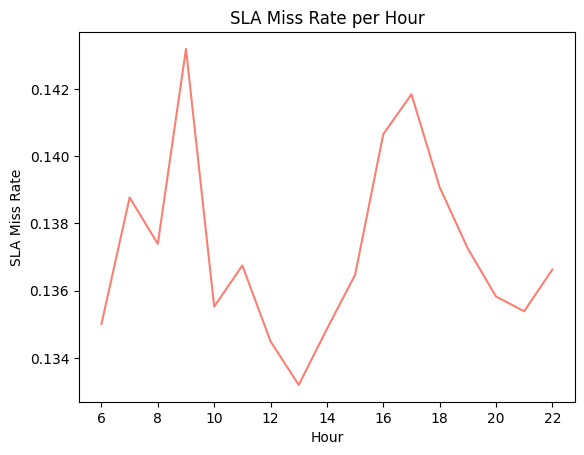

In [264]:
# Breakdown SLA Miss per Jam

df.groupby('hour')['delivery_sla_miss'].mean().plot(color='salmon')
plt.title('SLA Miss Rate per Hour')
plt.xlabel('Hour')
plt.ylabel('SLA Miss Rate')
plt.show()

**Catatan**
- Tingkat pelanggaran SLA relatif stabil sepanjang hari, tanpa perbedaan signifikan antara siang dan malam.
- Hal ini mengindikasikan bahwa keterlambatan pengiriman bukan dipengaruhi oleh kondisi eksternal seperti waktu operasional, melainkan merupakan masalah sistemik dalam proses internal, khususnya pada tahap picking.
- Tidak adanya lonjakan signifikan pada malam hari menunjukkan bahwa sistem operasional saat ini tidak cukup adaptif terhadap variasi kondisi operasional.
- Sebaliknya, performa yang konsisten buruk sepanjang hari mengindikasikan adanya inefisiensi struktural dalam proses fulfillment.

## **4. Berapa parah ketidakkonsistenan penulisan kategori produk yang di-input manual oleh admin Dark Store dari berbagai area?**

In [232]:
prod_raw.head(10)

,sku_id,product_name,category,is_perishable
0,SKU-AST0001,Produk FMCG Kering 0,Snacks,False
1,SKU-AST0002,Produk FMCG Kering 1,Snacks,False
2,SKU-AST0003,Produk FMCG Kering 2,minuman,False
3,SKU-AST0004,Sayur/Daging Segar 3,syr,True
4,SKU-AST0005,Produk FMCG Kering 4,snack,False
5,SKU-AST0006,Es Krim Rasa Strawberry 5,Fresh Produce,True
6,SKU-AST0007,Produk FMCG Kering 6,minuman,False
7,SKU-AST0008,Es Krim Rasa Strawberry 7,eskrim,True
8,SKU-AST0009,Produk FMCG Kering 8,Snacks,False
9,SKU-AST0010,Produk FMCG Kering 9,Beverages,False


In [233]:
prod_raw['category'].value_counts()

category
Snacks           77
Beverages        71
snack            57
Fresh Produce    53
minuman          45
Ice Cream        36
eskrim           23
syr              22
sayur            16
Name: count, dtype: int64

**Catatan**

Data Produk memiliki 9 kategori, akan tetapi terdapat inkonsistensi penulisan kategori

Inkonsistensi penulisan:
- Snacks dan snack

Inkonsistensi penggunaan bahasa:
- Beverages dan minuman
- Ice Cream dan eskrim
- Fresh Produce dan sayur

Singkatan ambigu:
- syr

**📝 Insight**
- Analisis terhadap kategori produk menunjukkan adanya inkonsistensi yang signifikan akibat input manual oleh admin dark store.
- Variasi penulisan mencakup perbedaan bahasa (misalnya "minuman" dan "beverages"), perbedaan bentuk kata ("snack" dan "snacks"), serta penggunaan singkatan yang ambigu seperti "syr".
Dari total 9 kategori yang teridentifikasi, hanya sekitar 5 kategori yang benar-benar unik, yang berarti sekitar 44% kategori merupakan duplikasi atau variasi yang tidak konsisten.
- Hal ini berpotensi menyebabkan distorsi dalam analisis dan pengambilan keputusan.

**🎯 Rekomendasi**

Untuk mencegah inkonsistensi di masa depan, disarankan untuk:
- Menggunakan dropdown atau predefined category pada sistem input
- Menerapkan validasi otomatis pada data entry
- Menyediakan standardisasi kategori secara terpusat

## **5. (Logical Error) Berapa banyak pesanan yang di sistem tercatat sudah 'Delivered' (Sampai ke Pelanggan), namun jam 'Picking Completed' (Selesai Dikemas) tercatat sesudah jam pengantaran tersebut?**

In [234]:
orders_raw.head(10)

,order_id,store_id,sku_id,picker_id,order_time,picking_completed_time,delivered_time,delivery_duration_mins,order_status
0,ORD-AST00000001,AST-101,SKU-AST0304,NaN,2023-12-31 18:19:13,2023-12-31 18:24:07,2023-12-31 18:31:37,12.0,Completed
1,ORD-AST00000002,AST-016,SKU-AST0021,PCK-854,2023-12-24 20:43:04,2023-12-24 20:48:10,2023-12-24 20:55:12,12.0,Completed
2,ORD-AST00000003,AST-072,SKU-AST0307,NaN,2023-12-16 22:34:38,2023-12-16 22:36:48,2023-12-16 22:42:54,8.0,Completed
3,ORD-AST00000004,AST-007,SKU-AST0065,PCK-785,2023-12-20 20:09:11,2023-12-20 20:11:23,2023-12-20 20:17:45,8.0,Completed
4,ORD-AST00000005,AST-046,SKU-AST0174,PCK-567,2024-01-02 06:32:18,2024-01-02 06:35:19,2024-01-02 06:45:48,13.0,Completed
5,ORD-AST00000006,AST-045,SKU-AST0060,PCK-155,2024-01-28 12:49:13,2024-01-28 12:53:42,2024-01-28 13:01:26,12.0,Completed
6,ORD-AST00000007,AST-111,SKU-AST0214,PCK-521,2024-02-03 18:36:45,2024-02-03 18:40:35,2024-02-03 18:47:54,11.0,Completed
7,ORD-AST00000008,AST-147,SKU-AST0317,PCK-971,2024-01-17 22:32:37,2024-01-17 22:35:50,2024-01-17 22:44:56,12.0,Completed
8,ORD-AST00000009,AST-059,SKU-AST0250,NaN,2023-12-04 19:49:15,2023-12-04 19:52:51,2023-12-04 20:05:21,16.0,Completed
9,ORD-AST00000010,AST-024,SKU-AST0021,NaN,2024-01-07 06:10:53,2024-01-07 06:13:49,2024-01-07 06:22:43,11.0,Completed


In [235]:
# Ubah Tipe Data

orders_raw['order_time'] = pd.to_datetime(orders_raw['order_time'])
orders_raw['picking_completed_time'] = pd.to_datetime(orders_raw['picking_completed_time'])
orders_raw['delivered_time'] = pd.to_datetime(orders_raw['delivered_time'])

In [236]:
# Filter Logical Error delivered_time < picking_completed_time

logical_error = orders_raw[
    orders_raw['delivered_time'] < orders_raw['picking_completed_time']
]

In [237]:
# Jumlah Logical Error

len(logical_error)

8910

In [238]:
# Proporsi Logical Error

len(logical_error) / len(orders_raw)

0.0297

**📝 Insight**
- Ditemukan sekitar 8.910 pesanan (±3% dari total) memiliki urutan waktu yang tidak logis, di mana pesanan tercatat telah dikirim sebelum proses picking selesai.
- Kondisi ini tidak mungkin terjadi secara operasional dan mengindikasikan adanya masalah dalam pencatatan sistem atau potensi manipulasi KPI oleh tim operasional.

In [239]:
# Cek Logical Error Lebih Lanjut

logical_error['order_status'].value_counts()

order_status
Completed    8910
Name: count, dtype: int64

**Catatan**
- Seluruh order yang terdeteksi memiliki urutan waktu tidak logis tetap tercatat completed.

In [240]:
# Cek Store yang Paling Banyak Punya Logical Error

logical_error.groupby('store_id').size().sort_values(ascending=False)

store_id
AST-131    85
AST-124    76
AST-050    75
AST-122    75
AST-106    73
           ..
AST-088    43
AST-020    42
AST-095    42
AST-051    41
AST-005    41
Length: 150, dtype: int64

**Catatan**
- Store AST-131 menjadi store dengan catatan logical error terbanyak dengan 85 kasus.
- AST-124, AST-050, AST-122, dan AST-106 berurutan mengisi daftar lima store teratas dengan kasus logical error.

**🎯Rekomendasi**
- Sistem harus enforce sequence event.
- Disable klik “delivered” sebelum picking selesai.
- Audit log operasional.

## **6. Berapa banyak Outliers ekstrem di mana durasi pengiriman (Delivery Duration) tercatat bernilai negatif atau memakan waktu ratusan ribu menit (bug sistem)?**

In [241]:
# Cek Distribusi

orders_raw['delivery_duration_mins'].describe()

count    300000.000000
mean         48.315547
std         570.397076
min         -15.000000
25%          11.000000
50%          13.000000
75%          15.000000
max        9999.000000
Name: delivery_duration_mins, dtype: float64

In [242]:
# Filter Outlier Ekstrem
# Normal: 5 - 30 Menit
# Toleransi: 0 - 120 Menit

outliers = orders_raw[
    (orders_raw['delivery_duration_mins'] < 0) |
    (orders_raw['delivery_duration_mins'] > 120)
]

len(outliers)

2014

In [243]:
# Proporsi Jumlah Outlier

len(outliers) / len(orders_raw)

0.006713333333333333

In [244]:
# Jumlah Outlier Negative dan Ekstrem

negative = orders_raw[orders_raw['delivery_duration_mins'] < 0]
extreme = orders_raw[orders_raw['delivery_duration_mins'] > 120]

len(negative), len(extreme)

(1032, 982)

In [245]:
# Cek Order Status Outliers

outliers['order_status'].value_counts()

order_status
Completed           1737
Refunded-Spoiled     156
Cancelled-Late       121
Name: count, dtype: int64

**📝 Insight**
- Ditemukan sejumlah pesanan dengan durasi pengiriman yang tidak masuk akal, termasuk nilai negatif dan durasi ekstrem hingga ribuan menit.
- Secara total, sekitar 0.67% data mengandung anomali tersebut.
- Meskipun proporsinya relatif kecil, nilai ekstrem ini dapat secara signifikan mengganggu metrik agregat seperti rata-rata durasi pengiriman, sehingga berpotensi menghasilkan insight yang menyesatkan.
- Nilai ekstrem seperti 9999 menit secara drastis meningkatkan nilai rata-rata (mean), sehingga tanpa proses pembersihan data, performa operasional akan terlihat jauh lebih buruk dari kondisi sebenarnya.

## **Analisis Lanjutan**

## **Fast-Moving Products**

In [246]:
# Produk yang Paling Sering Dibeli

fast_moving = df.groupby('sku_id').size().sort_values(ascending=False)
fast_moving.head(10)

sku_id
SKU-AST0325    727
SKU-AST0073    726
SKU-AST0236    718
SKU-AST0396    717
SKU-AST0094    717
SKU-AST0044    715
SKU-AST0174    715
SKU-AST0303    715
SKU-AST0135    714
SKU-AST0210    713
dtype: int64

In [247]:
# Join SKU dengan Nama Produk

fast_moving = df.groupby(['sku_id', 'product_name']).size().reset_index(name='order_count')
fast_moving.sort_values('order_count', ascending=False).head(10)

,sku_id,product_name,order_count
324,SKU-AST0325,Produk FMCG Kering 324,727
72,SKU-AST0073,Sayur/Daging Segar 72,726
235,SKU-AST0236,Produk FMCG Kering 235,718
395,SKU-AST0396,Produk FMCG Kering 395,717
93,SKU-AST0094,Produk FMCG Kering 93,717
43,SKU-AST0044,Produk FMCG Kering 43,715
173,SKU-AST0174,Es Krim Rasa Vanilla 173,715
302,SKU-AST0303,Produk FMCG Kering 302,715
134,SKU-AST0135,Produk FMCG Kering 134,714
209,SKU-AST0210,Es Krim Rasa Vanilla 209,713


In [248]:
# Picking Time per Product

product_picking = df.groupby('product_name')['picking_duration_mins'].mean().sort_values(ascending=False)
product_picking.head(10)

product_name
Produk FMCG Kering 227         4.122953
Produk FMCG Kering 336         4.101021
Es Krim Rasa Vanilla 374       4.094025
Produk FMCG Kering 224         4.091680
Es Krim Rasa Coklat 200        4.091438
Produk FMCG Kering 381         4.091249
Produk FMCG Kering 324         4.090692
Es Krim Rasa Strawberry 150    4.086282
Produk FMCG Kering 29          4.086222
Produk FMCG Kering 283         4.085507
Name: picking_duration_mins, dtype: float64

In [249]:
# Fast-Moving Picking Time

fast_moving_picking = df.groupby(['product_name']).agg(
    order_count=('order_id', 'count'),
    avg_picking=('picking_duration_mins', 'mean')
).sort_values('order_count', ascending=False)

fast_moving_picking.head(10)

,order_count,avg_picking
product_name,,
Produk FMCG Kering 324,727,4.090692
Sayur/Daging Segar 72,726,3.915565
Produk FMCG Kering 235,718,3.973027
Produk FMCG Kering 93,717,3.986030
Produk FMCG Kering 395,717,3.995212
Produk FMCG Kering 302,715,4.006224
Es Krim Rasa Vanilla 173,715,3.933147
Produk FMCG Kering 43,715,4.052867
Produk FMCG Kering 134,714,3.982026


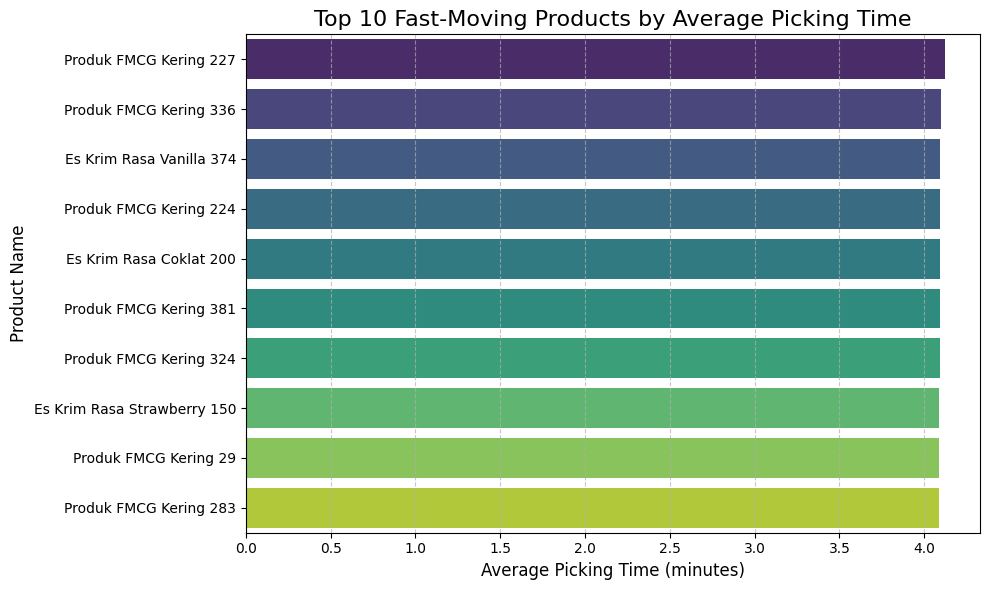

In [260]:
plt.figure(figsize=(10, 6))
# Sort by avg_picking to show products with the highest picking times
data_to_plot = fast_moving_picking.sort_values('avg_picking', ascending=False).head(10).reset_index()
sns.barplot(
    x='avg_picking',
    y='product_name',
    data=data_to_plot,
    palette='viridis'
)
plt.title('Top 10 Fast-Moving Products by Average Picking Time', fontsize=16)
plt.xlabel('Average Picking Time (minutes)', fontsize=12)
plt.ylabel('Product Name', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**📝 Insight**

- Analisis menunjukkan bahwa produk dengan frekuensi pemesanan tertinggi (fast-moving items), termasuk produk FMCG, sayuran, dan es krim, memiliki waktu picking yang relatif tinggi (sekitar 4 menit), jauh di atas target operasional 3 menit.
- Hal ini mengindikasikan bahwa produk-produk tersebut belum ditempatkan secara optimal di dalam gudang. Secara ideal, fast-moving items seharusnya ditempatkan di area yang paling mudah dijangkau untuk mempercepat proses picking.
- Ketidaksesuaian antara pola permintaan dan penempatan barang ini menjadi salah satu penyebab utama inefisiensi operasional.

**CATATAN**
- Perlu dicatat bahwa metrik waktu picking yang digunakan dalam analisis ini dihitung pada level order, bukan per item. Oleh karena itu, nilai rata-rata picking per produk merupakan pendekatan yang mengasumsikan distribusi waktu yang merata untuk setiap item dalam satu pesanan.
- Meskipun memiliki keterbatasan, pendekatan ini tetap relevan untuk mengidentifikasi pola umum dan perbandingan antar produk.

## **Waste Reduction**

In [250]:
# Spoilage vs Delivery Duration

df.groupby('order_status')['delivery_duration_mins'].mean()

order_status
Completed           12.430267
Refunded-Spoiled    12.427055
Name: delivery_duration_mins, dtype: float64

In [251]:
# Spoil vs Non-Spoil

df['is_spoiled'] = df['order_status'] == 'Refunded-Spoiled'

df.groupby('is_spoiled')['delivery_duration_mins'].mean()

is_spoiled
False    12.430267
True     12.427055
Name: delivery_duration_mins, dtype: float64

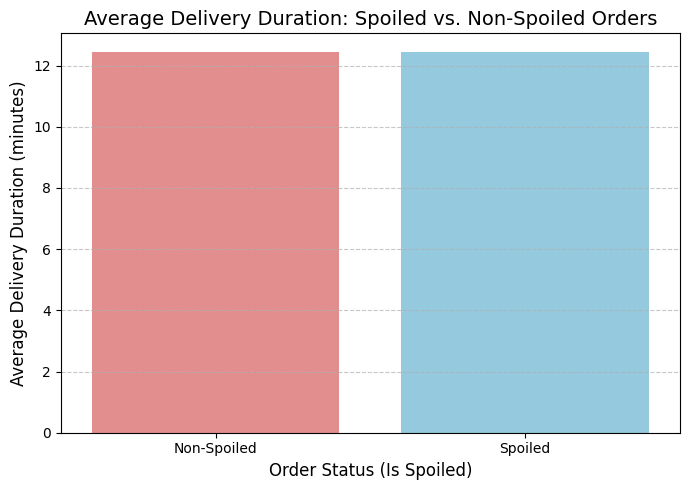

In [262]:
plt.figure(figsize=(7, 5))
mean_duration = df.groupby('is_spoiled')['delivery_duration_mins'].mean()
sns.barplot(x=mean_duration.index, y=mean_duration.values, palette=['lightcoral', 'skyblue'])
plt.title('Average Delivery Duration: Spoiled vs. Non-Spoiled Orders', fontsize=14)
plt.xlabel('Order Status (Is Spoiled)', fontsize=12)
plt.ylabel('Average Delivery Duration (minutes)', fontsize=12)
plt.xticks(ticks=[0, 1], labels=['Non-Spoiled', 'Spoiled'], rotation=0, fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [252]:
# Breakdown per Kategori

df[df['is_spoiled']].groupby('category')['delivery_duration_mins'].mean()

category
beverages        12.433333
fresh_produce    12.383127
ice_cream        12.427455
sayur            12.374625
snacks           12.453956
Name: delivery_duration_mins, dtype: float64

**📝 Insight**

- Analisis menunjukkan bahwa tidak terdapat perbedaan signifikan antara durasi pengiriman pesanan yang mengalami spoilage dan yang tidak.
- Hal ini mengindikasikan bahwa keterlambatan pengiriman bukan merupakan faktor utama penyebab kerusakan produk.
- Sebaliknya, kemungkinan besar spoilage terjadi pada tahap sebelum pengiriman, seperti selama proses picking atau penyimpanan di dalam dark store.
- Hal ini diperkuat dengan temuan bahwa waktu picking relatif tinggi dan tidak efisien, terutama untuk produk sensitif seperti es krim dan sayuran.

# **Insight & Recommendation**

Analisis terhadap operasional Quick Commerce Astro menunjukkan bahwa permasalahan utama tidak terletak pada faktor eksternal seperti waktu operasional atau kecepatan pengiriman, melainkan pada `inefisiensi internal dalam proses pemenuhan pesanan (fulfillment)`.

Dari sisi operasional, ditemukan bahwa `waktu picking secara konsisten melebihi target (±4 menit vs target 3 menit)` dan terjadi pada hampir seluruh dark store. Bahkan, produk dengan frekuensi pemesanan tertinggi (fast-moving items) juga mengalami keterlambatan dalam proses picking. Hal ini mengindikasikan bahwa `layout gudang tidak disusun berdasarkan pola permintaan`, sehingga memperlambat proses pencarian barang oleh picker.

Di sisi kualitas produk, analisis menunjukkan bahwa `spoilage tidak dipengaruhi secara signifikan oleh durasi pengiriman`, yang berarti kerusakan produk kemungkinan besar terjadi sebelum proses delivery. Temuan ini mengarah pada indikasi bahwa produk, terutama yang bersifat perishable seperti es krim dan sayuran, terlalu lama berada di luar kondisi penyimpanan optimal selama proses picking dan handling di dalam gudang.

Selain itu, ditemukan pula `masalah integritas data`, termasuk urutan waktu yang tidak logis dan durasi pengiriman yang tidak masuk akal. Hal ini menunjukkan adanya kelemahan dalam sistem pencatatan operasional, yang berpotensi menyebabkan distorsi dalam pengukuran performa dan membuka peluang manipulasi KPI.

## **Dark Store Optimization**

### **Finding**
Analisis menunjukkan bahwa rata-rata waktu picking di berbagai dark store berada di kisaran `±4 menit`, yang melebihi target operasional sebesar `≤3 menit`. Selain itu, produk dengan frekuensi pemesanan tertinggi (fast-moving items), termasuk produk FMCG, sayuran, dan es krim, juga memiliki waktu picking yang relatif tinggi.

### **Insight**
Fast-moving items yang seharusnya paling cepat diambil justru memiliki waktu picking yang tinggi. Hal ini mengindikasikan bahwa `layout gudang tidak disusun berdasarkan pola permintaan (demand-driven layout)`. Dengan kata lain, produk yang paling sering dibeli belum ditempatkan di lokasi yang paling mudah dijangkau oleh picker.

### **Business Impact**
Ketidakefisienan ini menyebabkan:
- Waktu picking menjadi lebih lama dari target.
- Keterlambatan dalam proses pemenuhan pesanan.
- Peningkatan risiko spoilage untuk produk sensitif seperti es krim dan sayuran.
- Penurunan kepuasan pelanggan akibat keterlambatan pengiriman.
- Dalam skala besar, hal ini dapat berdampak pada meningkatnya biaya operasional dan kerugian akibat refund.


### **Recommendation**
Untuk meningkatkan efisiensi operasional, disarankan:
- `Re-layout gudang berbasis data demand`, dengan menempatkan fast-moving items di area yang paling mudah dijangkau.
- Mengimplementasikan `zone picking system` untuk mengurangi waktu pencarian barang.
- Melakukan `analisis berkala terhadap pola pembelian` untuk memastikan layout tetap optimal.
- Memberikan prioritas picking untuk produk dengan frekuensi tinggi dan bersifat perishable.

## **Waste Reduction**

### **Finding**
Analisis menunjukkan bahwa tingkat spoilage (Refunded-Spoiled) terjadi di berbagai kategori produk, termasuk produk non-perishable. Selain itu, rata-rata durasi pengiriman antara pesanan yang mengalami spoilage dan yang tidak mengalami spoilage `tidak menunjukkan perbedaan yang signifikan` (±12.4 menit untuk keduanya).

### **Insight**
Tidak adanya perbedaan signifikan dalam durasi pengiriman antara pesanan yang rusak dan tidak rusak menunjukkan bahwa `keterlambatan delivery bukan merupakan penyebab utama spoilage`. Sebaliknya, kemungkinan besar kerusakan produk terjadi `sebelum proses pengiriman`, yaitu selama tahap picking atau penyimpanan di dalam dark store.

Temuan ini diperkuat dengan fakta bahwa waktu picking relatif tinggi (~4 menit) dan tidak efisien, bahkan untuk produk sensitif seperti es krim dan sayuran. Hal ini mengindikasikan bahwa produk tersebut mungkin `terpapar suhu lingkungan terlalu lama sebelum dikirim`, sehingga meningkatkan risiko mencair atau membusuk.

### **Business Impact**
Dampak dari kondisi ini meliputi:
- Tingginya jumlah refund akibat produk rusak.
- Kerugian langsung dari produk yang tidak dapat dijual kembali.
- Penurunan kepercayaan pelanggan terhadap kualitas layanan.
- Potensi peningkatan churn rate pelanggan.

Lebih jauh lagi, spoilage yang terjadi sebelum delivery menunjukkan adanya `inefisiensi internal yang tidak terlihat dari metrik SLA delivery`, sehingga berisiko tidak terdeteksi jika hanya fokus pada performa pengiriman.

### **Recommendation**
Untuk mengurangi tingkat spoilage, disarankan:
- `Mempercepat proses picking`, khususnya untuk produk perishable seperti es krim dan sayuran.
- Menerapkan `priority picking queue` untuk produk sensitif.
- Memastikan produk perishable tetap berada dalam `cold storage hingga mendekati waktu pengiriman`.
- Memperketat `SOP cold chain handling`, termasuk penggunaan insulated container selama proses picking.
- Mengurangi waktu produk berada di luar suhu optimal sebelum diserahkan ke rider.

Dengan fokus pada perbaikan proses internal ini, tingkat spoilage dapat ditekan secara signifikan tanpa harus bergantung pada percepatan delivery.

## **Data Integrity**

### **Finding**
Ditemukan beberapa anomali dalam data operasional:
- Sekitar `~3% pesanan (±8.910 order)` memiliki urutan waktu yang tidak logis, di mana pesanan tercatat telah delivered sebelum proses picking completed.
- Sekitar `~0.67% data` memiliki durasi pengiriman yang tidak masuk akal, termasuk nilai negatif dan durasi ekstrem hingga ribuan menit.

### **Insight**
Anomali ini menunjukkan adanya `kelemahan dalam sistem pencatatan operasional`, di mana urutan proses tidak tervalidasi dengan baik. Secara operasional, tidak mungkin pengiriman terjadi sebelum proses picking selesai, sehingga data tersebut mengindikasikan:
- Keterlambatan atau ketidaktepatan input manual oleh picker atau rider
- Tidak adanya validasi urutan event dalam sistem
- Potensi manipulasi input untuk memenuhi target KPI operasional

Selain itu, keberadaan nilai durasi ekstrem (seperti 9999 menit) menunjukkan adanya `bug sistem atau error dalam logging waktu`, yang dapat merusak akurasi metrik performa.

### **Business Impact**
Dampak dari masalah ini sangat signifikan:
- `Distorsi metrik performa`, seperti rata-rata waktu delivery dan SLA compliance.
- Risiko `misleading decision-making`, karena data tidak merepresentasikan kondisi operasional sebenarnya.
- Potensi `moral hazard`, di mana tim operasional dapat memanipulasi input untuk terlihat memenuhi KPI.
- Menurunnya kepercayaan terhadap dashboard dan sistem monitoring internal.

Dalam jangka panjang, hal ini dapat menyebabkan perusahaan mengambil keputusan yang tidak tepat karena berbasis pada data yang tidak valid.

### **Recommendation**
Untuk meningkatkan integritas data, disarankan:
- Menerapkan `validation rule pada sistem`, sehingga urutan proses harus logis (picking selesai sebelum delivery).
- Menambahkan `timestamp auto-capture` untuk mengurangi ketergantungan pada input manual.
- Menetapkan `threshold validasi durasi`, misalnya durasi tidak boleh negatif atau melebihi batas tertentu (misalnya 120 menit).
- Mengaktifkan `audit log dan anomaly detection system` untuk mendeteksi data yang tidak wajar secara real-time.
- Mengurangi kemungkinan manipulasi dengan `mengunci tombol aksi berdasarkan urutan proses`.

Dengan perbaikan ini, kualitas data dapat ditingkatkan sehingga analisis dan pengambilan keputusan menjadi lebih akurat dan dapat dipercaya.